# Handeling Missing values

### Its technique are :
          - Remove missing rows (not preferable actually)
          - Impute (univariate and multivariate)

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/data_science_job.csv')

In [3]:
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
895,28699,city_16,0.91,Male,Has relevent experience,no_enrollment,NaN,NaN,4.0,100-500,Pvt Ltd,48.0,0.0
17244,30628,city_16,0.91,Male,Has relevent experience,no_enrollment,Graduate,Humanities,10.0,10000+,Pvt Ltd,29.0,0.0
2537,23050,city_16,0.91,NaN,Has relevent experience,Full time course,Graduate,STEM,5.0,10/49,Pvt Ltd,109.0,0.0
292,31692,city_160,0.92,Male,Has relevent experience,Full time course,Graduate,STEM,20.0,10000+,Pvt Ltd,40.0,0.0
3366,4237,city_160,0.92,NaN,No relevent experience,Part time course,Graduate,STEM,15.0,NaN,NaN,20.0,0.0


In [19]:
df.shape

(19158, 13)

In [4]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [21]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [44]:
df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

In [7]:
df['enrolled_university'].unique()

array(['no_enrollment', 'Full time course', nan, 'Part time course'],
      dtype=object)

In [8]:
df['education_level'].unique()

array(['Graduate', 'Masters', 'High School', nan, 'Phd', 'Primary School'],
      dtype=object)

In [9]:
df['company_size'].unique()

array([nan, '50-99', '<10', '10000+', '5000-9999', '1000-4999', '10/49',
       '100-500', '500-999'], dtype=object)

In [10]:
df['company_type'].unique()

array([nan, 'Pvt Ltd', 'Funded Startup', 'Early Stage Startup', 'Other',
       'Public Sector', 'NGO'], dtype=object)

In [12]:
df['training_hours'].nunique()

241

In [14]:
df['city_development_index'].nunique()

93

In [20]:
# major_discipline
df['major_discipline'].unique()

array(['STEM', 'Business Degree', nan, 'Arts', 'Humanities', 'No Major',
       'Other'], dtype=object)

In [15]:
df['experience'].unique()

array([20., 15.,  5.,  0., 11., 13.,  7., 17.,  2., 16.,  1.,  4., 10.,
       14., 18., 19., 12.,  3.,  6.,  9.,  8., nan])

In [17]:
df.describe()

,enrollee_id,city_development_index,experience,training_hours,target
count,19158.000000,18679.000000,19093.000000,18392.000000,19158.000000
mean,16875.358179,0.828951,9.928036,65.185787,0.249348
std,9616.292592,0.123334,6.505268,59.885626,0.432647
min,1.000000,0.448000,0.000000,1.000000,0.000000
25%,8554.250000,0.740000,4.000000,23.000000,0.000000
50%,16982.500000,0.903000,9.000000,47.000000,0.000000
75%,25169.750000,0.920000,16.000000,88.000000,0.000000
max,33380.000000,0.949000,20.000000,336.000000,1.000000


city_development_index = median <br>
experience = mean <br>
training_hours = median 



# Complete case analysis(CCA)
   ### --> Also called list-wise-deletion of cases, consists in discarding observation(row) 
###           where values in any of the variables are missing.<br>
###       --> It means literally analyzing only those observations for which there is information 
###             in all  of the variables in the dataset.

### Assumptions for CAA 
       - Missing completely at random.
       - Having less than 5% data are missing.
       - If columns has more than 95% missing remove the column.

In [22]:
# it seperates data having less than 5% nan data 

cols = [var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [24]:
# find out how many data left after removing those rows

len(df[cols].dropna()) / len(df)

0.8968577095730244

In [25]:
new_df = df[cols].dropna()
df.shape ,new_df.shape

((19158, 13), (17182, 5))

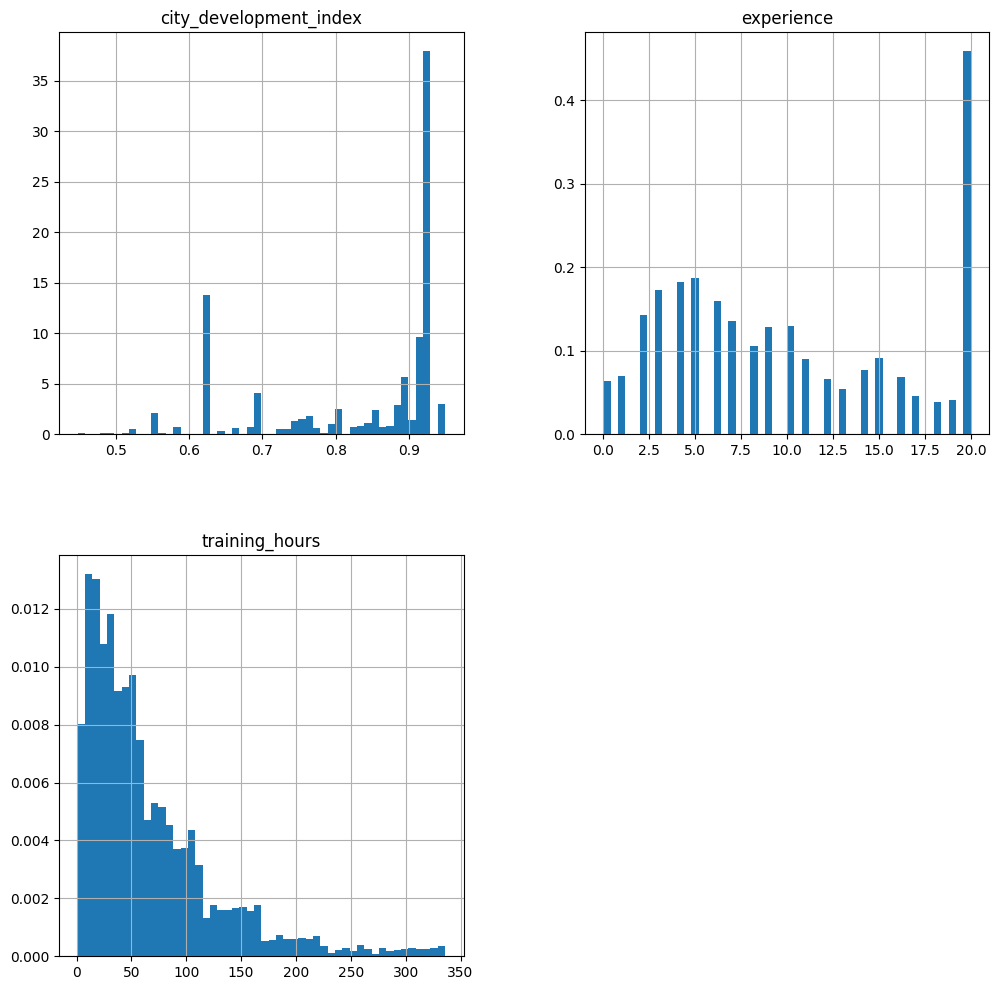

In [38]:
new_df.hist(bins=50, density=True, figsize=(12,12))
plt.show()

<Axes: >

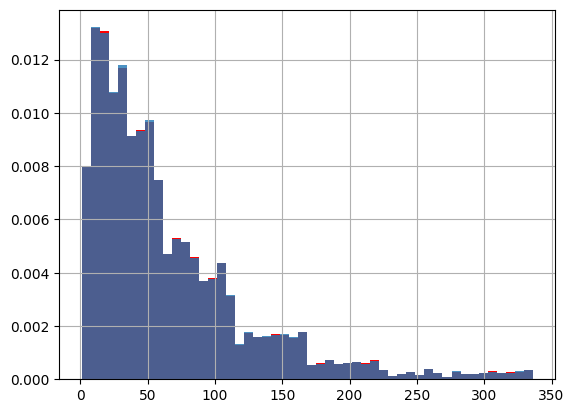

In [40]:
fig = plt.figure()
ax= fig.add_subplot(111)

#original data
df['training_hours'].hist(bins=50, ax=ax, density=True,color='red')

# data after cca , the arguement alpha make the color transparent so
# we can see the pverlay of 2 distribution.

new_df['training_hours'].hist(bins=50, ax=ax, density=True,alpha =0.8)

<Axes: >

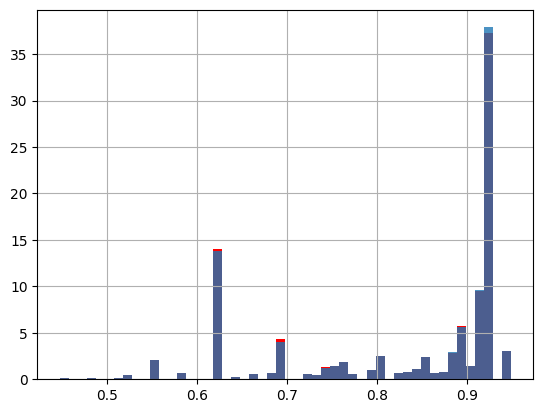

In [41]:
fig = plt.figure()
ax= fig.add_subplot(111)

#original data
df['city_development_index'].hist(bins=50, ax=ax, density=True,color='red')

# data after cca , the arguement alpha make the color transparent so
# we can see the pverlay of 2 distribution.

new_df['city_development_index'].hist(bins=50, ax=ax, density=True,alpha =0.8)

<Axes: >

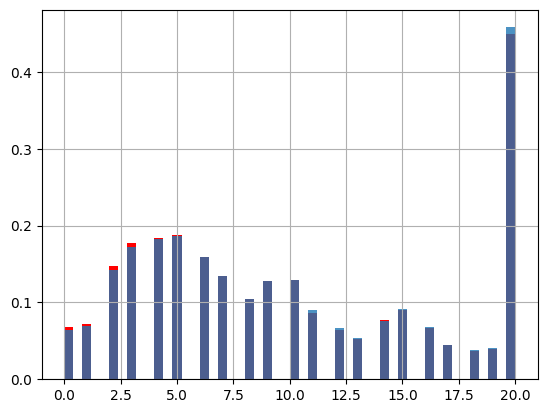

In [42]:
fig = plt.figure()
ax= fig.add_subplot(111)

#original data
df['experience'].hist(bins=50, ax=ax, density=True,color='red')

# data after cca , the arguement alpha make the color transparent so
# we can see the pverlay of 2 distribution.

new_df['experience'].hist(bins=50, ax=ax, density=True,alpha =0.8)

In [50]:
temp= pd.concat([
    # percentage of obs per category, orginal data 
    df['enrolled_university'].value_counts()/len(df),

        # cca data
    new_df['enrolled_university'].value_counts()/len(new_df)
],axis=1
              )
# add column names
temp.columns =['original','cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [51]:
temp= pd.concat([
    # percentage of obs per category, orginal data 
    df['education_level'].value_counts()/len(df),

        # cca data
    new_df['education_level'].value_counts()/len(new_df)
],axis=1
              )
# add column names
temp.columns =['original','cca']
temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
